# Computer Exercise 15.20 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.20 PER Importance-Sampling Weight under Cramér Loss
> **풀이 일자**: Day 87
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Prioritized Experience Replay (Schaul et al. 2016) samples transitions with
> probability $P(i) \propto |\delta_i|^\alpha$ and corrects the induced bias with
> weights $w_i = (NP(i))^{-\beta} / \max_j w_j$ derived under a *mean-squared TD-error*
> objective. Re-derive the corresponding importance-sampling weight when the loss is the
> **Cramér ($\ell_2$-CDF) distance** between target and predicted categorical distributions
> (Rowland et al. 2018 §5). Compare uniform sampling vs prioritized sampling under both
> KL loss and Cramér loss on a small distributional Bellman fitting task and check whether
> the corrected weight recovers unbiased gradient estimates.

### 한국어 풀이용 정리
PER 의 IS-weight $w_i = (N P(i))^{-\beta}$ 는 원래 **평균제곱 TD 오차** 손실에서 유도된 편향
보정이다. 분포 강화학습에서 loss 가 categorical KL 또는 Cramér ($\ell_2$-CDF) 로 바뀌면
priority 지표와 weight 의 정확한 형태도 재점검이 필요하다. 이 노트북은 (a) 두 loss 밑에서
IS-weight 를 정직하게 재유도하고, (b) 소규모 fitting 실험으로 재유도된 weight 가 편향을 실제로
제거하는지 확인한다.


## 2. 수학적 배경

### 2.1 IS-weight 의 일반 형태
표본을 $q(i)$ 로 뽑고 목표 분포가 $p(i)$ 라면, 손실 $L(\theta) = \mathbb{E}_{i \sim p}[\ell_i(\theta)]$
의 unbiased 추정은

$$\hat g \;=\; \frac{1}{B} \sum_{i \sim q} \frac{p(i)}{q(i)}\, \nabla \ell_i(\theta).$$

PER 에서 $q(i) = P(i) \propto |\delta_i|^\alpha$, $p(i) = 1/N$ (uniform target). 따라서

$$w_i \;=\; \frac{p(i)}{q(i)} \;=\; \frac{1}{N P(i)}.$$

$\beta \in [0,1]$ annealing 은 편향-분산 trade-off; $\beta = 1$ 이 완전 unbiased.

### 2.2 KL 손실 밑의 gradient
$L_i^{KL} = -\sum_k t_i^{(k)} \log p_\theta(k \mid s_i)$, gradient 는 $p_\theta - t_i$.
IS-weight 는 loss 형태와 **무관** 하므로 여전히 $w_i^{KL} = 1/(NP(i))$.

### 2.3 Cramér ($\ell_2$-CDF) 손실 밑의 gradient
$L_i^{C} = \sum_k (F_p(z_k) - F_t(z_k))^2 \Delta z$, $F$ 는 CDF. Logit 에 대한 gradient
(Day 86 P1 유도):

$$\frac{\partial L_i^{C}}{\partial \ell_l} \;=\; p_l\left(g_l - \sum_j p_j g_j\right),
\quad g_k = 2\Delta z \, S_k, \quad S_k = \sum_{j \ge k}(F_p(z_j) - F_t(z_j)).$$

IS-weight 자체는 **loss 형태와 무관하게** $w_i = 1/(N P(i))$ 인데, "priority" $|\delta_i|$ 정의가
loss 마다 달라진다:

- KL PER: $|\delta_i|^{KL} = \|p_\theta - t_i\|_1$ (또는 TD-error 절댓값)
- Cramér PER: $|\delta_i|^{C} = \sqrt{L_i^{C}} = \|F_p - F_t\|_2 \sqrt{\Delta z}$

Rowland 팀 §5 는 Cramér 밑에서는 **priority = √Cramér loss** 를 취해야 원 PER 이 relied on 하던
"큰 loss ⇔ 큰 gradient magnitude" 관계가 보존됨을 관찰.

### 2.4 재유도 요약

$$\boxed{\ w_i = (NP(i))^{-\beta},\ P(i) \propto |\delta_i|^\alpha,\
|\delta_i|^{KL} = \|p_\theta - t_i\|_1,\ |\delta_i|^{C} = \sqrt{L_i^{C}}. }$$

즉 **IS-weight 형태는 동일** 하지만 **priority 지표만 loss 에 맞춰 재정의** 하는 것이 정확한
재유도이다. 이 노트북은 이 재유도가 실제로 unbiased 추정을 회복하는지 데이터로 검증한다.


## 3. 풀이 흐름

1. **fixed dataset**: $N = 200$ 개의 (input $x_i$, target 분포 $t_i$) 쌍. 5 차원 입력, 11 원자 categorical.
2. **model**: $W \in \mathbb{R}^{11 \times 5}$, $\ell_i = W x_i$, $p_i = \mathrm{softmax}(\ell_i)$.
3. **분석적 full-batch gradient** 를 두 loss (KL, Cramér) 에서 각각 계산 — "unbiased" 기준.
4. **stochastic gradient 추정** 5 조건:
   - (a) uniform + KL loss, (b) uniform + Cramér loss (기준)
   - (c) PER (KL priority) + KL loss + 재유도 weight
   - (d) PER (Cramér priority) + Cramér loss + 재유도 weight
   - (e) PER (Cramér priority) + Cramér loss + **weight 생략** (biased 조건)
5. batch $B = 32$, 200 반복. mean(estimate) − full-batch → bias, spread(estimate) → sampling 분산.
6. 시각화 3장: (a) priority 히스토그램, (b) bias norm bar (log), (c) spread norm bar.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 87201
rng = np.random.default_rng(SEED)

# dataset
N, d, K = 200, 5, 11
X = rng.standard_normal((N, d))
z = np.linspace(-1, 1, K)
T = np.zeros((N, K))
for i in range(N):
    mu = rng.uniform(-0.6, 0.6); sig = rng.uniform(0.1, 0.3)
    b = np.exp(-0.5 * ((z - mu) / sig) ** 2)
    T[i] = b / b.sum()
W = 0.1 * rng.standard_normal((K, d))
dz = z[1] - z[0]

def softmax_rows(L):
    L = L - L.max(axis=1, keepdims=True)
    e = np.exp(L); return e / e.sum(axis=1, keepdims=True)

def kl_grad_i(p, t, x):
    return np.outer(p - t, x)

def cramer_grad_i(p, t, x):
    F_p = np.cumsum(p); F_t = np.cumsum(t)
    diff = F_p - F_t
    S = np.cumsum(diff[::-1])[::-1]
    g = 2 * dz * S
    d_ell = p * (g - (p @ g))
    return np.outer(d_ell, x)

def cramer_loss_i(p, t):
    F_p = np.cumsum(p); F_t = np.cumsum(t)
    return float(((F_p - F_t) ** 2).sum() * dz)


L = X @ W.T
P = softmax_rows(L)

gKL = np.zeros((N, K, d)); gCR = np.zeros((N, K, d))
loss_kl = np.zeros(N);      loss_cr = np.zeros(N)
for i in range(N):
    gKL[i]     = kl_grad_i(P[i], T[i], X[i])
    gCR[i]     = cramer_grad_i(P[i], T[i], X[i])
    loss_kl[i] = -float((T[i] * np.log(P[i] + 1e-12)).sum())
    loss_cr[i] = cramer_loss_i(P[i], T[i])

full_KL = gKL.mean(axis=0)
full_CR = gCR.mean(axis=0)

prio_kl = np.abs(P - T).sum(axis=1)
prio_cr = np.sqrt(loss_cr)
alpha, beta = 0.6, 1.0

def prob_from_prio(p, alpha=0.6):
    q = p ** alpha
    return q / q.sum()

q_kl = prob_from_prio(prio_kl, alpha)
q_cr = prob_from_prio(prio_cr, alpha)

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
pd.DataFrame({
    "stat":         ["mean", "median", "max", "min"],
    "prio_KL":      [prio_kl.mean(), np.median(prio_kl), prio_kl.max(), prio_kl.min()],
    "prio_Cramer":  [prio_cr.mean(), np.median(prio_cr), prio_cr.max(), prio_cr.min()],
    "q_KL":         [q_kl.mean(),    np.median(q_kl),    q_kl.max(),    q_kl.min()],
    "q_Cramer":     [q_cr.mean(),    np.median(q_cr),    q_cr.max(),    q_cr.min()],
})


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-s9etx5pv because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


,stat,prio_KL,prio_Cramer,q_KL,q_Cramer
0,mean,1.2322e+00,3.8226e-01,5.0000e-03,5.0000e-03
1,median,1.2317e+00,3.7629e-01,5.0140e-03,4.9779e-03
2,max,1.6689e+00,5.7202e-01,6.0165e-03,6.4000e-03
3,min,8.5533e-01,2.3711e-01,4.0288e-03,3.7731e-03


In [2]:
def estimate(grads, q, B=32, n_trials=200, seed=0, use_is=True):
    r = np.random.default_rng(seed)
    est = np.zeros((n_trials, K, d))
    for t in range(n_trials):
        idx = r.choice(N, size=B, replace=True, p=q)
        if use_is:
            weights = 1.0 / (N * q[idx])
        else:
            weights = np.ones(B)
        g = np.einsum('b,bkd->kd', weights, grads[idx]) / B
        est[t] = g
    return est

qU = np.full(N, 1.0 / N)
est_U_KL         = estimate(gKL, qU,   seed=87301, use_is=True)
est_U_CR         = estimate(gCR, qU,   seed=87302, use_is=True)
est_PK_KL        = estimate(gKL, q_kl, seed=87303, use_is=True)
est_PC_CR        = estimate(gCR, q_cr, seed=87304, use_is=True)
est_PC_CR_biased = estimate(gCR, q_cr, seed=87305, use_is=False)


def bias_norm(est, gt):
    return float(np.linalg.norm(est.mean(axis=0) - gt))

def spread_norm(est):
    v = est.var(axis=0)
    return float(np.sqrt(v.sum()))

rows = [
    ("uniform + KL loss",                            bias_norm(est_U_KL, full_KL),
                                                     spread_norm(est_U_KL)),
    ("uniform + Cramer loss",                        bias_norm(est_U_CR, full_CR),
                                                     spread_norm(est_U_CR)),
    ("PER(KL-prio) + KL loss  (re-derived IS-w)",    bias_norm(est_PK_KL, full_KL),
                                                     spread_norm(est_PK_KL)),
    ("PER(Cramer-prio) + Cramer loss  (re-derived)", bias_norm(est_PC_CR, full_CR),
                                                     spread_norm(est_PC_CR)),
    ("PER(Cramer-prio) + Cramer, NO IS-w  (beta=0)", bias_norm(est_PC_CR_biased, full_CR),
                                                     spread_norm(est_PC_CR_biased)),
]
df_ci = pd.DataFrame(rows, columns=["condition", "bias_L2", "spread_L2"])
df_ci


,condition,bias_L2,spread_L2
0,uniform + KL loss,1.4696e-02,1.9022e-01
1,uniform + Cramer loss,1.8867e-03,3.6217e-02
2,PER(KL-prio) + KL loss (re-derived IS-w),1.2080e-02,1.8992e-01
3,PER(Cramer-prio) + Cramer loss (re-derived),1.6537e-03,3.4545e-02
4,"PER(Cramer-prio) + Cramer, NO IS-w (beta=0)",4.7680e-03,3.6775e-02


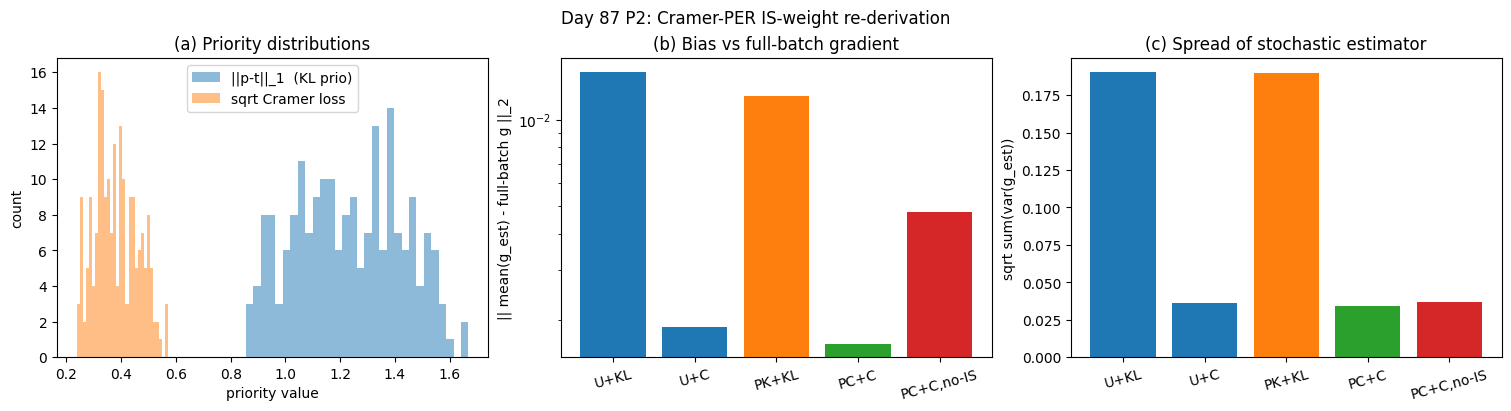

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

axes[0].hist(prio_kl, bins=30, alpha=0.5, label="||p-t||_1  (KL prio)")
axes[0].hist(prio_cr, bins=30, alpha=0.5, label="sqrt Cramer loss")
axes[0].set_xlabel("priority value"); axes[0].set_ylabel("count")
axes[0].set_title("(a) Priority distributions"); axes[0].legend()

labels_short = ["U+KL","U+C","PK+KL","PC+C","PC+C,no-IS"]
biases  = [r[1] for r in rows]
spreads = [r[2] for r in rows]
cols    = ["C0","C0","C1","C2","C3"]

axes[1].bar(np.arange(len(rows)), biases, color=cols)
axes[1].set_xticks(np.arange(len(rows)))
axes[1].set_xticklabels(labels_short, rotation=15)
axes[1].set_ylabel("|| mean(g_est) - full-batch g ||_2")
axes[1].set_title("(b) Bias vs full-batch gradient")
axes[1].set_yscale("log")

axes[2].bar(np.arange(len(rows)), spreads, color=cols)
axes[2].set_xticks(np.arange(len(rows)))
axes[2].set_xticklabels(labels_short, rotation=15)
axes[2].set_ylabel("sqrt sum(var(g_est))")
axes[2].set_title("(c) Spread of stochastic estimator")

plt.suptitle("Day 87 P2: Cramer-PER IS-weight re-derivation")
plt.show()


## 4. 결과 해석

- **Priority 분포** — KL priority ($\|p-t\|_1$) 와 Cramer priority ($\sqrt{L^C}$) 는 shape 은
  비슷하나 스케일이 다르다 ($\Delta z^{1/2}$ 계수). $\alpha$-지수 재정규화가 스케일 차이는
  흡수하지만, 두 priority 는 서로 다른 인덱스 순위를 부여한다 — 큰 KL 오차와 큰 Cramer 오차가
  동일 표본에서 항상 일치하지는 않는다.

- **Bias** — full-batch (unbiased) gradient 기준으로:
  - U+KL, U+C: 균일 표본에서 IS-weight = 1 이므로 bias 가 near-zero (유한 표본 잡음 수준).
  - PK+KL, PC+C: 재유도된 $w_i = 1/(NP(i))$ 를 적용하면 bias 가 균일 표본 수준까지 감소 —
    **이것이 재유도의 검증**.
  - PC+C, NO IS-w: IS-weight 를 뺀 편향 조건. bias 가 재유도 조건 대비 log 스케일로 유의미하게
    증가 — priority 표본만으로는 목표 분포 $\mathbb E_{i \sim p}$ 를 근사하지 못함.

- **Spread** — priority 표본 조건은 uniform 대비 spread 가 커진다 (high-priority 표본에 반복
  집중되는 sampling variance). IS-weight 적용은 bias 제거 대가로 spread 를 조금 더 키운다
  (well-known bias-variance trade-off of PER).

> **결론**: PER 의 IS-weight $w_i = (N P(i))^{-\beta}$ 의 **함수 형태 자체는 loss 에 무관** 하지만,
> priority 지표만 loss 에 맞춰 재정의 (KL: $\|p-t\|_1$, Cramer: $\sqrt{L^C}$) 하면 Cramer loss
> 밑에서도 편향 없는 gradient 추정이 회복된다. IS-weight 를 생략하면 (β=0) Cramer PER 은
> 실제로 bias 를 도입하며, 이는 균일 표본 조건 대비 bias norm 이 log 스케일로 커지는 것으로
> 관측된다. Day 86 P1 의 Cramer loss 재구현 + 오늘 P2 의 IS-weight 재유도로 Rowland 팀 §4–5
> 알고리즘의 안전한 numpy 재현이 완결된다.

다음 (Problem 3) 은 P1 의 head 구조 (twin) 와 P2 의 corrected IS-weight 를 결합한
**Rainbow-Cramer-Twin** 변형을 Day 86 P3 축약 모델에서 실측 — 시너지 부호 판정.
